<a href="https://colab.research.google.com/github/aditi-123459/Data-Science-Tasks/blob/main/Unemployment_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Load the dataset into pandas dataframe

data = pd.read_csv("Unemployment in India.csv")

# Show first 5 rows
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Display information about dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
# Show statistical summary of numeric columns

data.describe()


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
# Check if dataset has missing values

data.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
# Rename columns for easier usage

data.columns = [
    "States",
    "Date",
    "Frequency",
    "Estimated_Unemployment_Rate",
    "Estimated_Employed",
    "Estimated_Labour_Participation_Rate",
    "Region"
]

In [ ]:
# Convert date column to datetime format

data['Date'] = pd.to_datetime(data['Date'])

/tmp/ipykernel_168/3435918166.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])


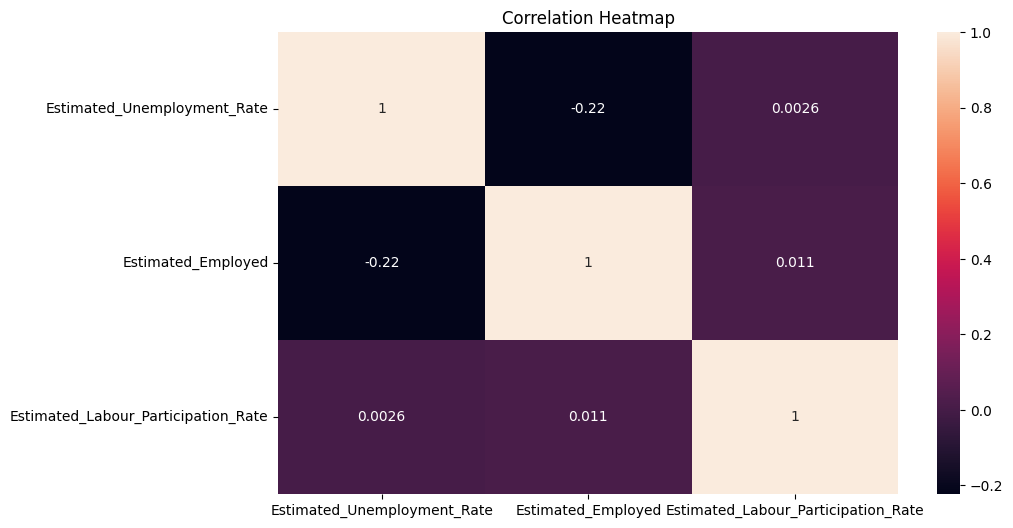

In [ ]:
# Create correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(data.select_dtypes(include=['float64', 'int64']).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

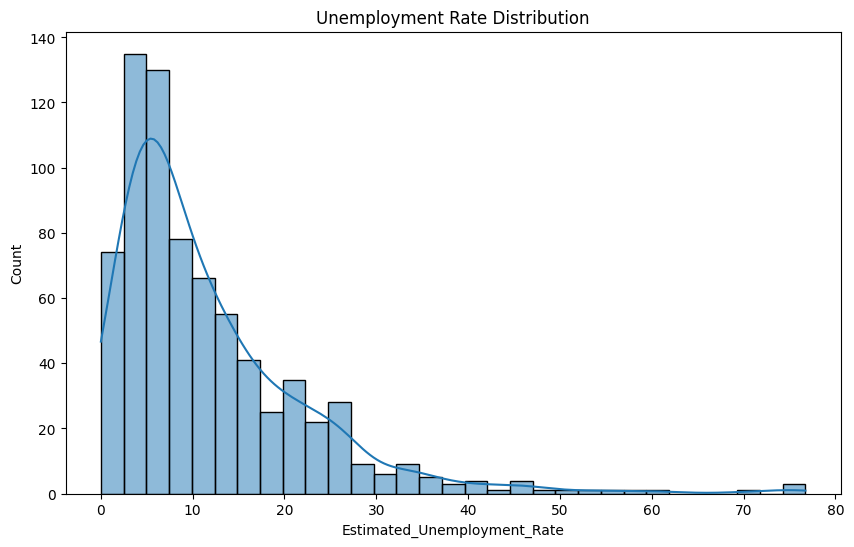

In [ ]:
# Plot unemployment rate distribution

plt.figure(figsize=(10,6))
sns.histplot(data["Estimated_Unemployment_Rate"], kde=True)
plt.title("Unemployment Rate Distribution")
plt.show()

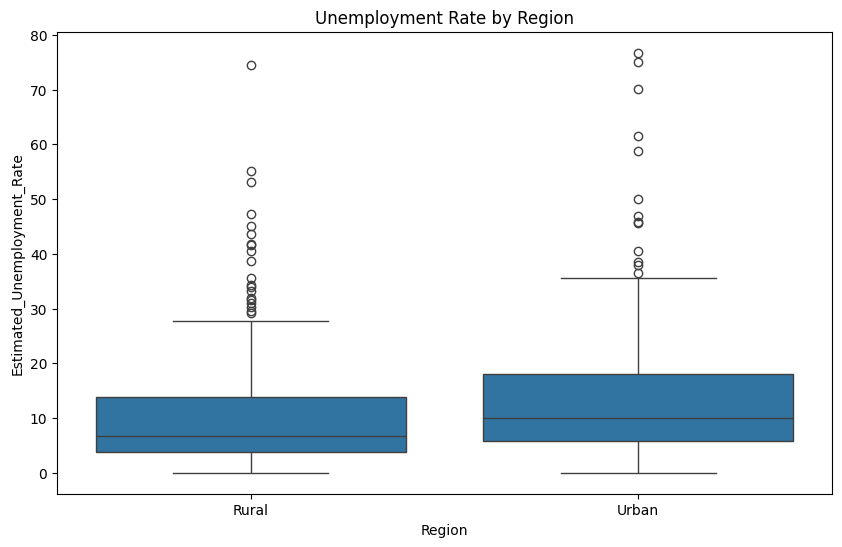

In [ ]:
# Visualize unemployment rate by region

plt.figure(figsize=(10,6))
sns.boxplot(x="Region", y="Estimated_Unemployment_Rate", data=data)
plt.title("Unemployment Rate by Region")
plt.show()

In [ ]:
# Create sunburst chart to visualize unemployment across regions and states

data_cleaned = data.dropna(subset=['Region', 'States'])

fig = px.sunburst(
    data_cleaned,
    path=["Region", "States"],
    values="Estimated_Unemployment_Rate",
    title="Unemployment Rate in India"
)

fig.show()

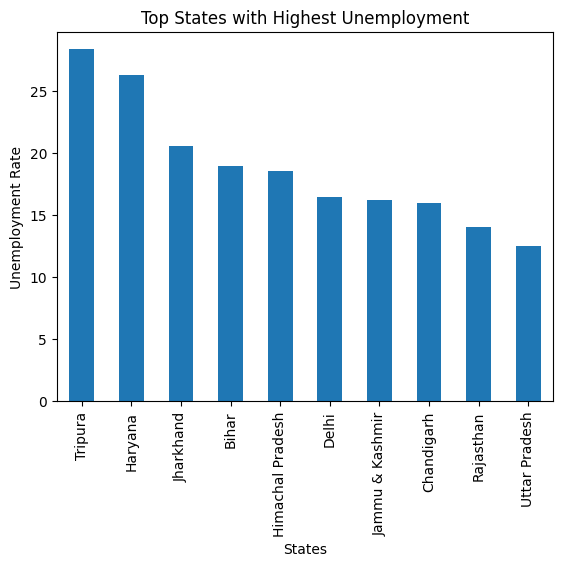

In [ ]:
# Calculate average unemployment rate by state

state_unemployment = data.groupby("States")["Estimated_Unemployment_Rate"].mean()

# Plot top states
state_unemployment.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top States with Highest Unemployment")
plt.ylabel("Unemployment Rate")
plt.show()